In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt

In [6]:
nn_samps = np.load("nn_results/ode/nn_samps_16384_4.npy")
mcmc_samps = np.load("mcmc_results/mcmc_samps_1_65536.npy")
cond_vars_nn = np.load("nn_results/ode/cond_vars_1.npy")
cond_vars_mcmc = np.load("mcmc_results/cond_vars_1.npy")

In [7]:
# nn_samps = nn_samps[:, 0, 1:2]
nn_samps.shape

(16384, 4)

In [56]:
cond_vars_nn

array([0.11869603])

<Axes: ylabel='Density'>

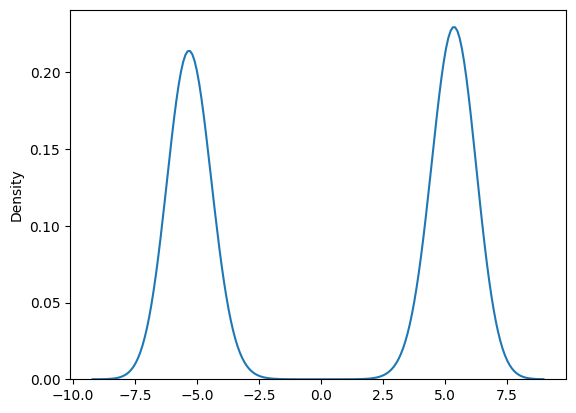

In [8]:
kdeplot(nn_samps[:, 0])

<Axes: ylabel='Density'>

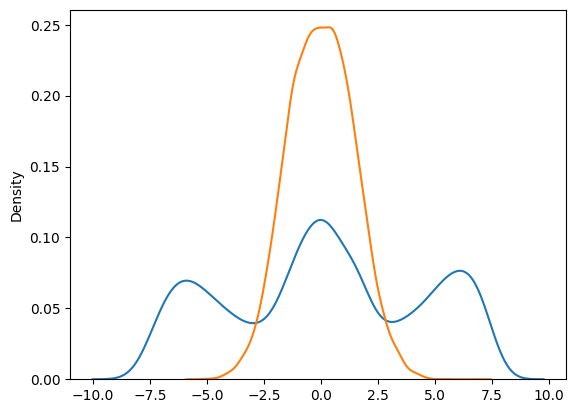

In [51]:
kdeplot(nn_samps[3, :])
kdeplot(mcmc_samps[1, :])

In [49]:
mcmc_samps.T

array([[-2.44845366, -2.45239735, -2.45239735, -3.5330658 ],
       [ 1.29442203,  0.41608751, -0.68946612, -0.33428127],
       [-1.4627533 , -1.82132769, -1.82132769, -1.75808048],
       ...,
       [-1.78120434, -1.78120434, -1.94873703, -1.74651229],
       [-0.72995722, -1.02962983, -1.02962983, -1.02553594],
       [-0.66443455, -0.57771927,  0.16330159, -0.58374602]],
      shape=(16384, 4))

In [35]:
cond_vars_nn.tolist()

[-3.5647616853240907,
 0.09326188557027049,
 -3.3054810426222163,
 1.3637277267963572]

In [19]:
cond_vars_mcmc

array([-3.56476169,  0.09326189, -3.30548104,  1.36372773])

In [58]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [65]:
import jax
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.networks.flow_networks import MLP
import optax
from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)
from triangular_transport.flows.interpolants import (
    trig_interpolant,
    trig_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

epochs = 6500
seed = 1
# Train the one model
train_dim = 65536
key = jax.random.key(seed=seed)
key, key1 = jax.random.split(key=key, num=2)
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="banana", rng=None, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 3
# hidden_layer_list = [1024] * 8
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2000,
    decay_steps=steps,
    end_value=1e-5,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(schedule)
)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

velocity = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

velocity.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 71/214500 [00:02<1:25:45, 41.67it/s] 

step = 0, train_loss = -0.0008326483657583594


  5%|▍         | 10085/214500 [00:16<04:39, 732.57it/s]

step = 10000, train_loss = -2.927858829498291


...

step = 200000, train_loss = -3.147759199142456


 98%|█████████▊| 210105/214500 [04:48<00:05, 737.73it/s]

step = 210000, train_loss = -3.092902421951294


100%|██████████| 214500/214500 [04:54<00:00, 728.10it/s]

step = 214499, train_loss = -2.66567063331604


In [76]:
cond_vars_nn = np.load("nn_results/ode/cond_vars_4.npy")
cond_vars = cond_vars_nn.tolist()
cond_samples = velocity.conditional_sample(
    cond_values=cond_vars,
    nsamples=train_dim,
    u0_cond=None,
)

In [81]:
import jax.numpy as jnp
cond_sample_list = [cond_sample[:, yu_dimension[0]:] for cond_sample in cond_samples]
cond_samps = jnp.hstack(cond_sample_list)

In [82]:
cond_samps.shape

(65536, 4)

<Axes: ylabel='Density'>

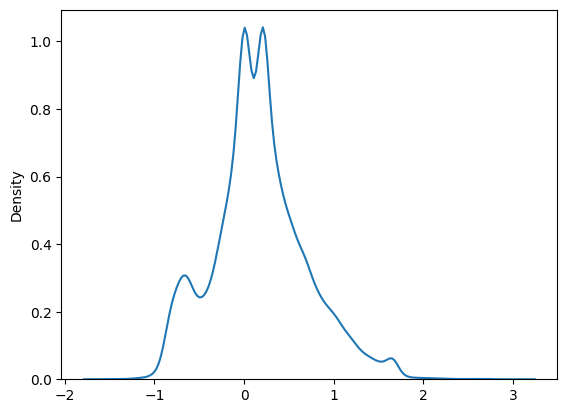

In [87]:
kdeplot(cond_samps[:, 3])

In [ ]:
cond_vars_nn

array([-3.56476169,  0.09326189, -3.30548104,  1.36372773])

: 

In [71]:
cond_vars_nn.tolist()

[0.11869603267454742]